In [1]:
import pandas as pd

train_df = pd.read_csv("../data/train.csv")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# 1. Target Feature

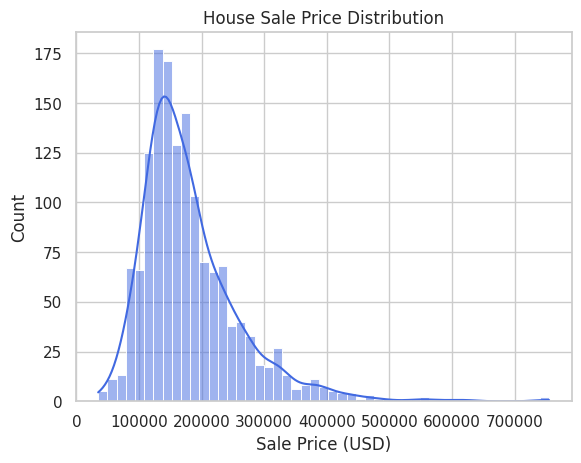

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập theme cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# Vẽ histogram kết hợp đường cong mật độ (KDE)
sns.histplot(train_df['SalePrice'], kde=True, color='royalblue')
plt.title('House Sale Price Distribution')
plt.xlabel('Sale Price (USD)')
plt.ylabel('Count')
plt.show()


# 2. Độ tương quan

In [3]:
corr_matrix = train_df.corr(numeric_only = True)

corr_matrix["SalePrice"].sort_values(key = abs, ascending = False)


SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass      -0.084284
OverallCond     -0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePr

In [4]:
strong_corr = corr_matrix["SalePrice"][corr_matrix["SalePrice"].abs() >= 0.3]
strong_features = strong_corr.drop("SalePrice").index.tolist()

# 2.1 Vẽ Scatter Plot

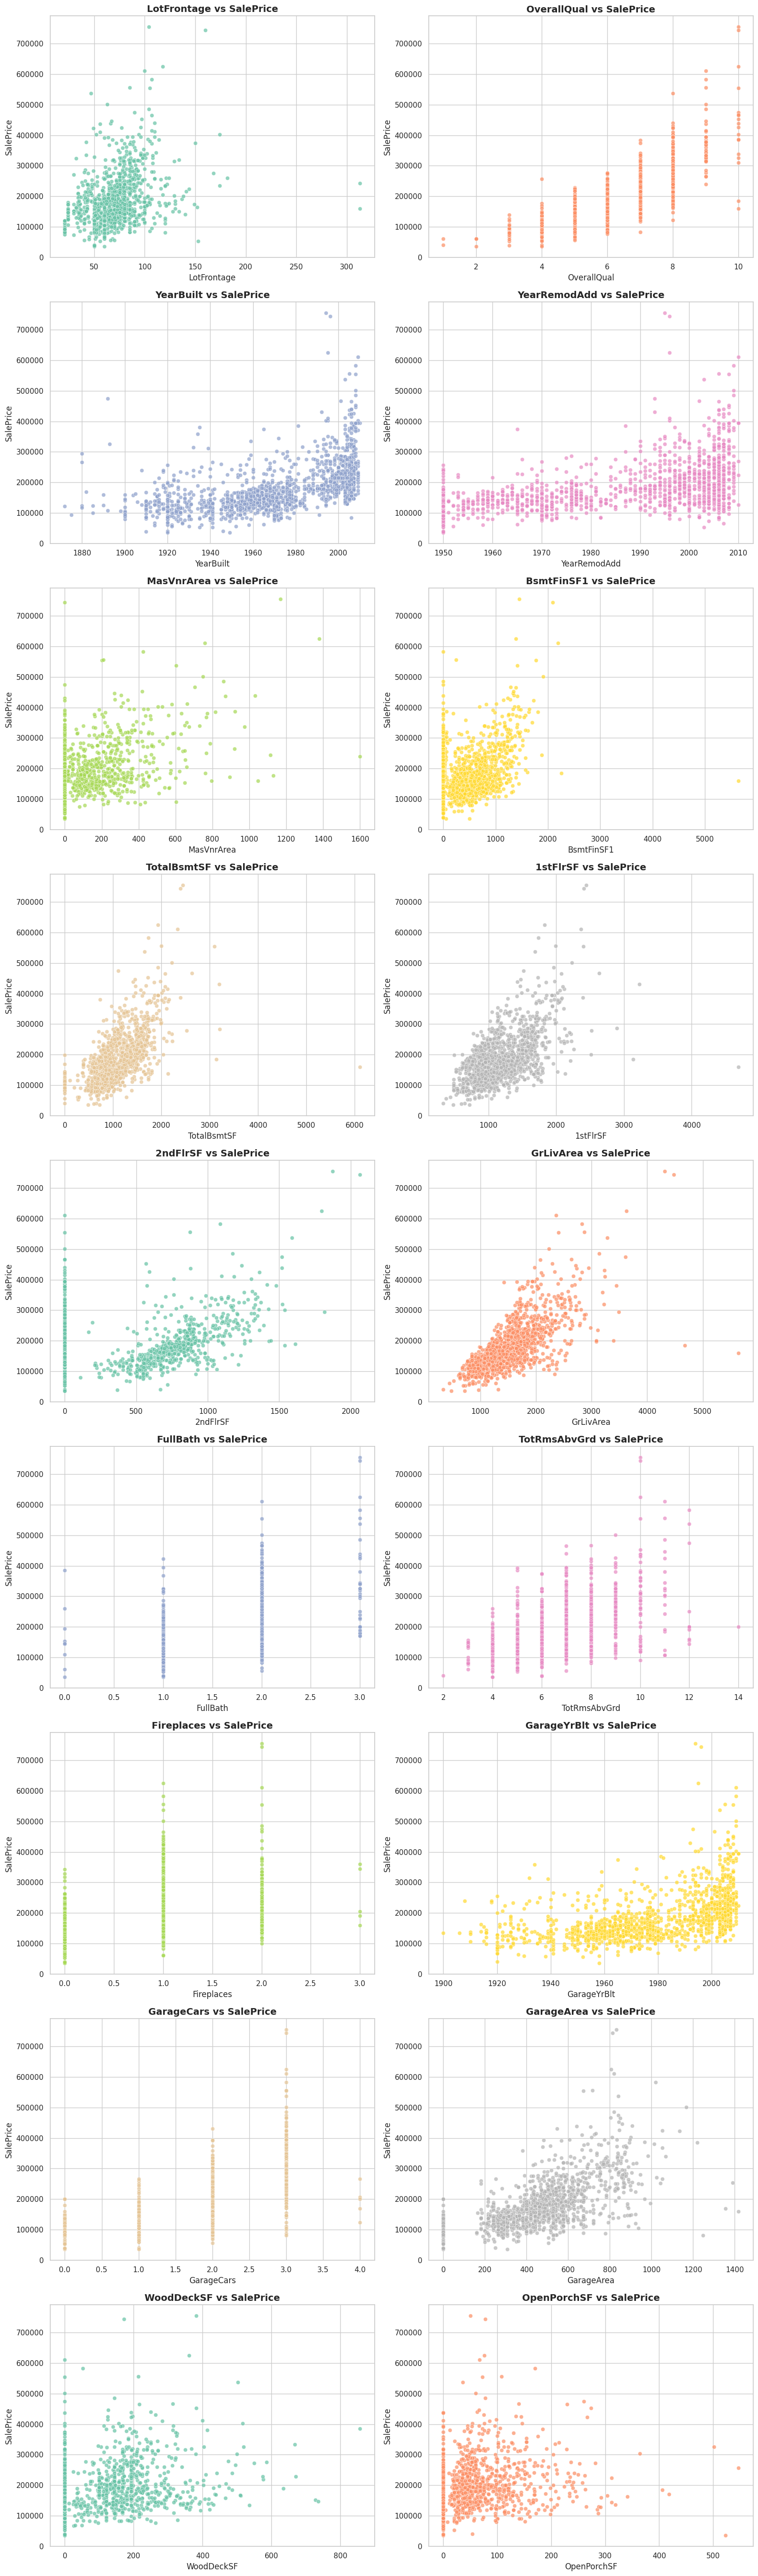

In [5]:
from utils import plot_scatter_vs_target

plot_scatter_vs_target(train_df, strong_features, 'SalePrice', cols = 2)

# 2.2 Vẽ hist

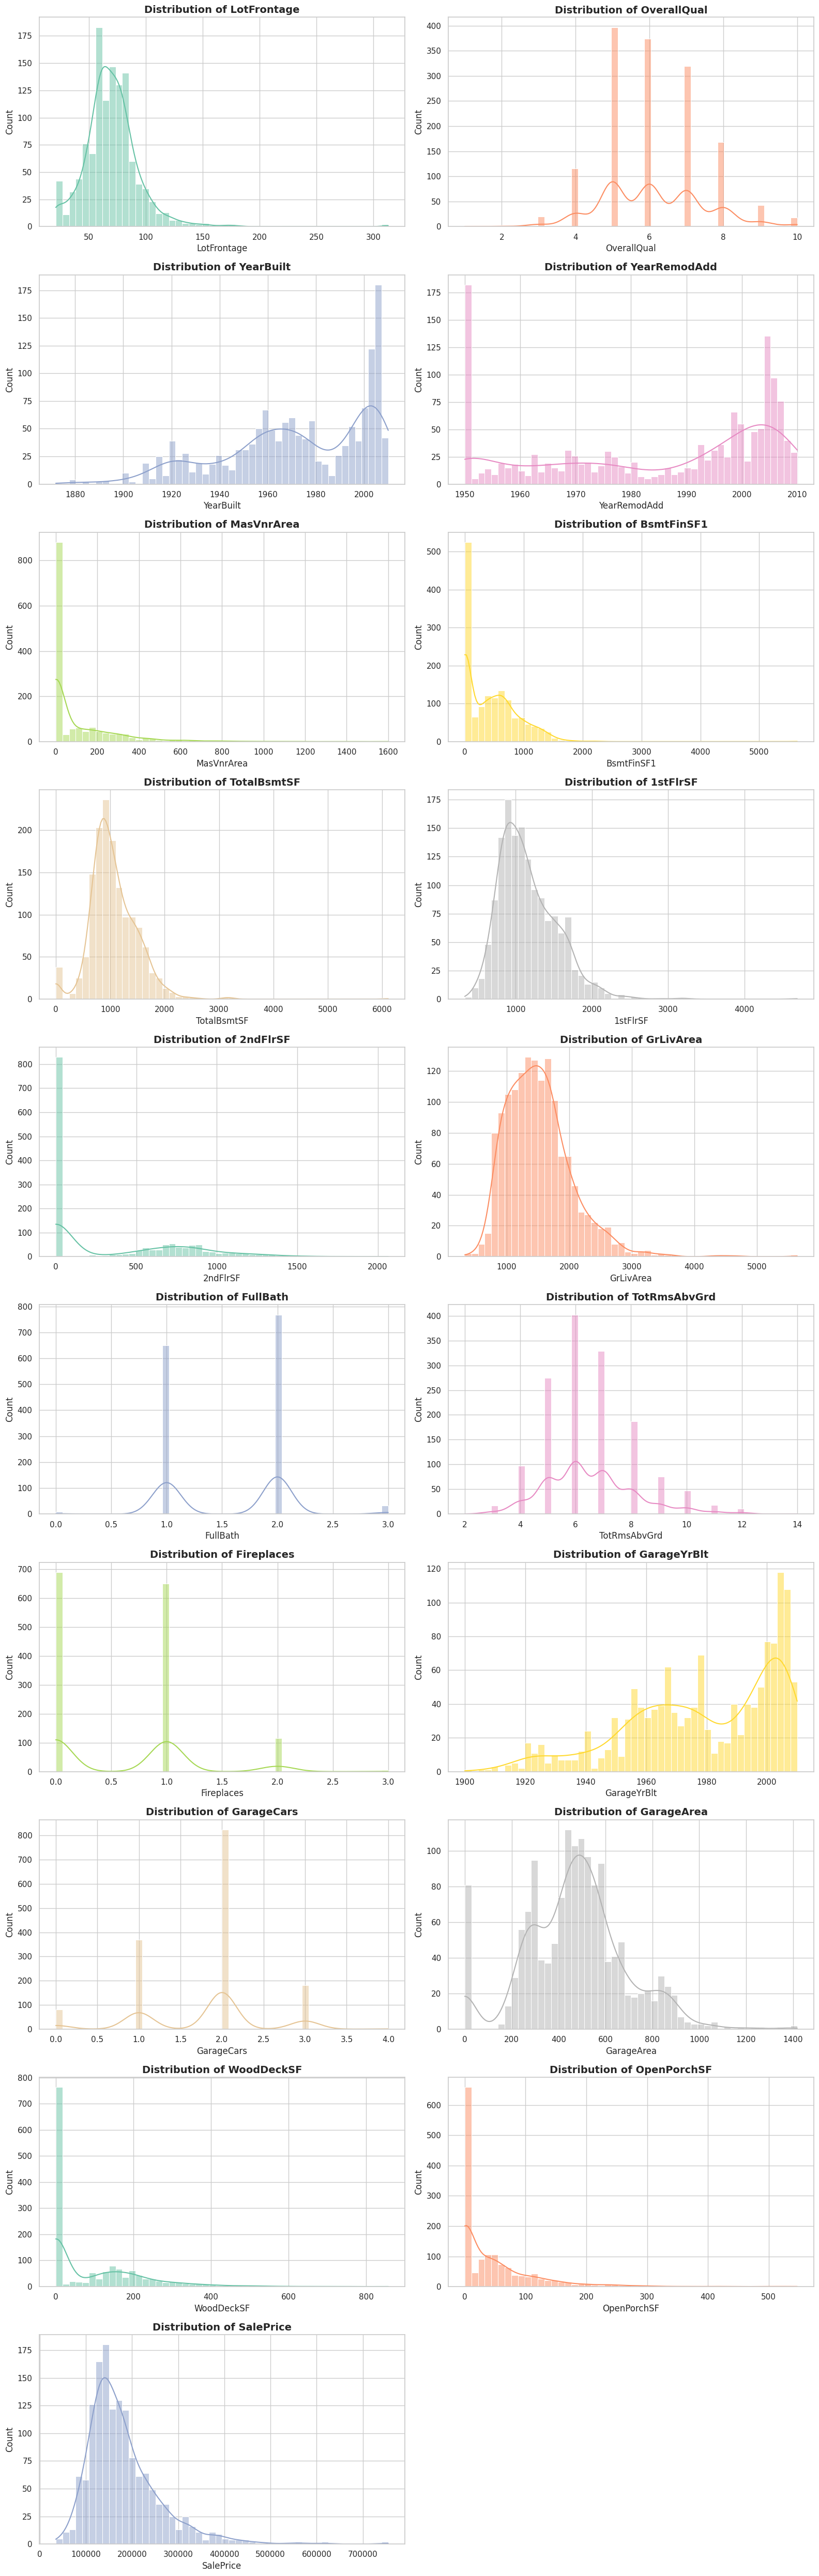

In [6]:
from utils import plot_histograms

features_with_target = strong_corr.index.tolist()

plot_histograms(train_df, features_with_target)